In [1]:
from datasets import load_dataset

import re
import spacy
from string import punctuation

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt

In [2]:
raw = load_dataset("csv", data_files="cw_data.csv", column_names=["text", "label"])
dataset = raw["train"]

In [3]:
class LemmaCleaner:  
    NORMALISATION_MAP = {
        'acct': 'account',    # ~45 occurrences
        'accts': 'accounts',  # 1 occurrence
        'pls': 'please',      # ~12 occurrences
        'plz': 'please',
        'pwd': 'password',    # 1 occurrence
        'wout': 'without',    # w/out after punctuation removal
        'emial': 'email',     # 8 occurrences
        'wat': 'what',        # ~38 occurrences
        '2': 'to',            # ~30 occurrences
        'cant': 'cannot',     # 7 occurrences — expands so negation is preserved
        'didnt': 'did not',   # 1 occurrence
        'doesnt': 'does not',
        'dont': 'do not',
        'wont': 'will not',
        'isnt': 'is not',
    }

    def __init__(self, data):
        self.data = data
        self.nlp = spacy.load("en_core_web_sm")
        self.negations = {'not', 'no', 'cannot'}
        self.stop_words = set(self.nlp.Defaults.stop_words) - self.negations

        self.lowered = self.lowercase(self.data)
        self.punctuated = self.remove_punctuation(self.lowered)
        self.normalised = self.normalise_text(self.punctuated)
        self.lemmatised = self.tokenise_and_lemmatise(self.normalised)
        self.rejoined = self.rejoin(self.lemmatised)

    def lowercase(self, texts):
        return [t.lower() for t in texts]
    
    def remove_punctuation(self, texts):
        extra = '—–""''…' 
        all_punct = punctuation + extra
        cleaned_texts = []
        for t in texts:
            t = t.translate(str.maketrans('', '', all_punct))
            cleaned_texts.append(t)
        return cleaned_texts
    
    def normalise_text(self, texts):
        normalised = []
        for t in texts:
            for informal, formal in self.NORMALISATION_MAP.items():
                t = re.sub(r'\b' + re.escape(informal) + r'\b', formal, t)
            normalised.append(t)
        return normalised

    def remove_standalone_numerics(self, tokenised_texts):
        cleaned = []
        for t in tokenised_texts:
            cleaned.append([w for w in t if not re.fullmatch(r'\d+', w)])
        return cleaned
    
    def remove_stop_words(self, tokenised_texts):
        cleaned_texts = []
        for t in tokenised_texts:
            cleaned_texts.append([w for w in t if w not in self.stop_words])
        return cleaned_texts
    
    def tokenise_and_lemmatise(self, texts):
        result = []
        for t in texts:
            doc = self.nlp(t)
            tokens = [token.lemma_ for token in doc
                    if token.text not in self.stop_words
                    and not re.fullmatch(r'\d+', token.text)
                    and token.text.strip()]
            result.append(tokens)
        return result
    
    def rejoin(self, lemmatised_texts):
        return [' '.join(tokens) for tokens in lemmatised_texts]

In [4]:
parsed = LemmaCleaner(dataset["text"])

In [5]:
parsed.lemmatised[:5]

[['tracking', 'show', 'ship', 'no', 'delivery', 'help'],
 ['partial', 'shipment', 'track', 'separately'],
 ['invalid', 'email', 'enter', 'happen'],
 ['recover', 'account', 'suspend'],
 ['email', 'update', 'fail', 'error', 'fix']]

In [6]:
vectoriser = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = vectoriser.encode(parsed.rejoined)
y = dataset["label"]

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y, test_size=0.2, random_state=42, stratify=y
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


                         precision    recall  f1-score   support

       account_recovery       0.80      1.00      0.89         4
        billing_history       1.00      0.75      0.86         4
           data_privacy       1.00      0.75      0.86         4
         delete_account       1.00      1.00      1.00         5
            login_issue       1.00      1.00      1.00         3
  notification_settings       1.00      1.00      1.00         5
         order_tracking       0.80      1.00      0.89         4
          payment_issue       0.86      0.86      0.86         7
         refund_request       0.75      0.75      0.75         4
         reset_password       1.00      1.00      1.00         4
         shipping_delay       1.00      1.00      1.00         6
subscription_management       0.67      0.80      0.73         5
        two_factor_auth       1.00      0.50      0.67         2
           update_email       1.00      1.00      1.00         5

               accuracy

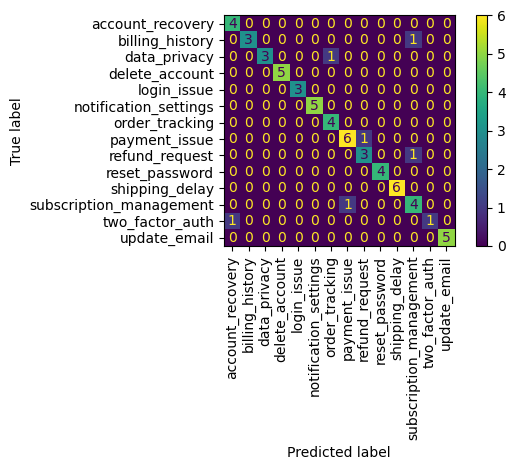

Macro F1: 0.928 (+/- 0.020)


In [7]:
model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced'    # handles your imbalanced classes
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
# Add to Semantic notebook
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=90)
plt.tight_layout()
plt.show()
scores = cross_val_score(model, embeddings, y, cv=5, scoring='f1_macro')
print(f"Macro F1: {scores.mean():.3f} (+/- {scores.std():.3f})")

In [8]:
errors = [(text, true, pred) 
          for text, true, pred in zip(dataset["text"], y_test, y_pred) 
          if true != pred]

for text, true, pred in errors:
    print(f"Text: {text}")
    print(f"True: {true} | Predicted: {pred}\n")

Text: view personal data and download copy?
True: billing_history | Predicted: subscription_management

Text: billing history not updating… wat do?
True: payment_issue | Predicted: refund_request

Text: cant pay with credit card immediately?
True: refund_request | Predicted: subscription_management

Text: expedite account recovery possible?
True: two_factor_auth | Predicted: account_recovery

Text: I'm unable to sign in — is this because my account is locked?
True: data_privacy | Predicted: order_tracking

Text: Why can't I log into my account on my tablet?
True: subscription_management | Predicted: payment_issue

